<a href="https://colab.research.google.com/github/kirat-anand-68/NEURAL_NETWORKS/blob/main/Tensorflow2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

In [ ]:
X=tf.range(-100,100,4)

In [ ]:
y=X+10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [ ]:
X_train = X[:40] # first 40 training samples
X_test=X[40:] # the last 10 samples
y_train = y[:40]
y_test=y[40:]

len(X_train),len(X_test),len(y_train),len(y_test)

(40, 10, 40, 10)

In [ ]:
import matplotlib.pyplot as plt


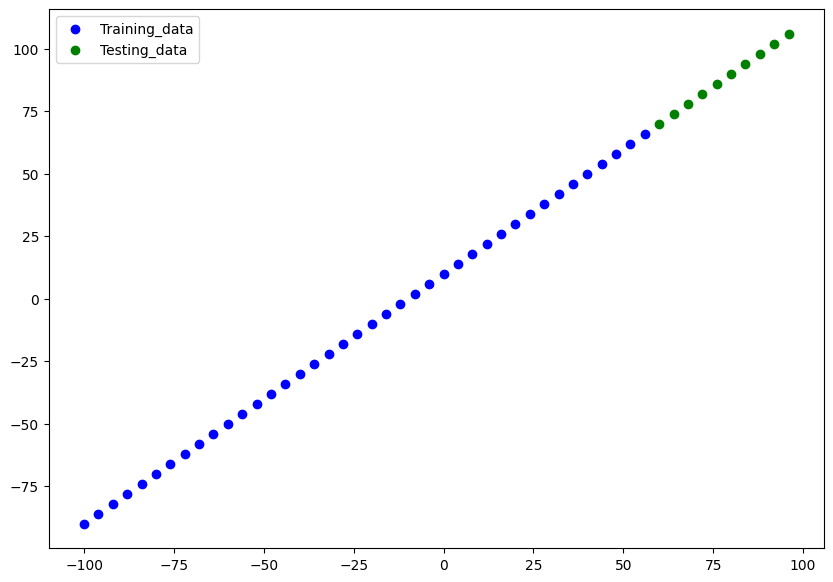

In [ ]:
## Visulaizing the data
# data onto the training and the test set
plt.figure(figsize=(10,7))
plt.scatter(X_train,y_train,c="b",label="Training_data")
plt.scatter(X_test,y_test,c="g",label="Testing_data")
plt.legend();


In [ ]:
# 1. Create a model
model=tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

In [ ]:
model.summary


<bound method Model.summary of <Sequential name=sequential, built=False>>

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["mae"]
)

history = model.fit(X_train, y_train, epochs=500, verbose=0)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 905 (3.54 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 604 (2.36 KB)

In [ ]:
model.fit(X_train,y_train,epochs=100,verbose=0)

In [ ]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

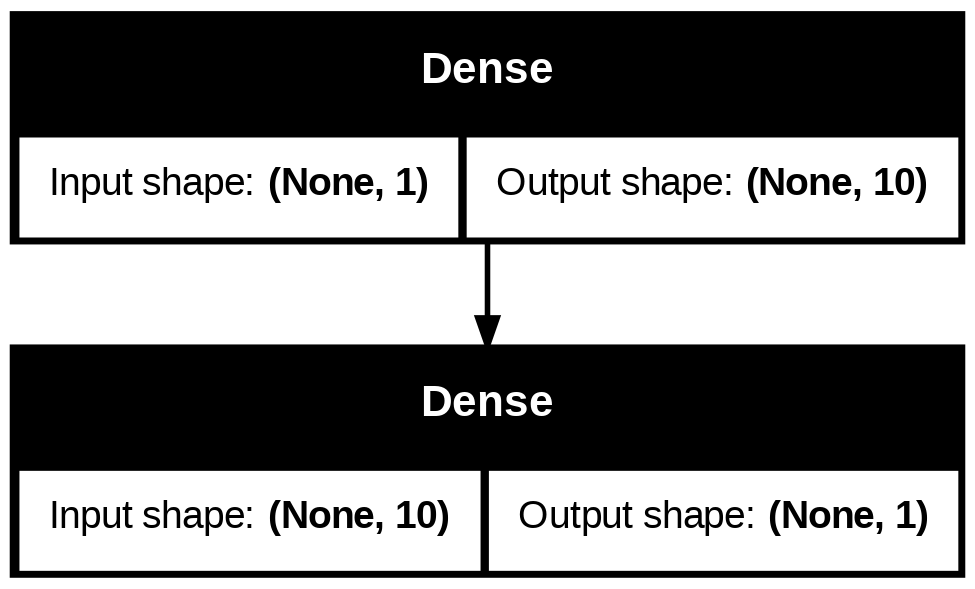

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model=model , show_shapes=True)

In [ ]:
#make some prediction
y_pred=model.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


array([[46.414253],
       [49.395176],
       [52.376106],
       [55.357033],
       [58.337955],
       [61.318886],
       [64.29981 ],
       [67.28075 ],
       [70.261665],
       [73.24259 ]], dtype=float32)

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [ ]:
# Let's create a plotting function


In [ ]:
y_pred = model.predict(X_test)
y_pred = tf.squeeze(y_pred)

print(y_pred)
print(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
tf.Tensor(
[ 68.06964   71.94621   75.82254   79.698715  83.5744    87.45008
  91.323166  95.19411   99.06433  102.93286 ], shape=(10,), dtype=float32)
tf.Tensor([ 70  74  78  82  86  90  94  98 102 106], shape=(10,), dtype=int32)


In [ ]:
def plot_prediction(train_data=X_train,
                    training_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=y_pred
                    ):
# plo the trainigdata
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_data,c="b",label="Training_data")
  plt.scatter(test_data,test_labels,c="g",label="Testing_data")
  plt.scatter(test_data,predictions,c="r",label="Predictions");
  plt.legend();

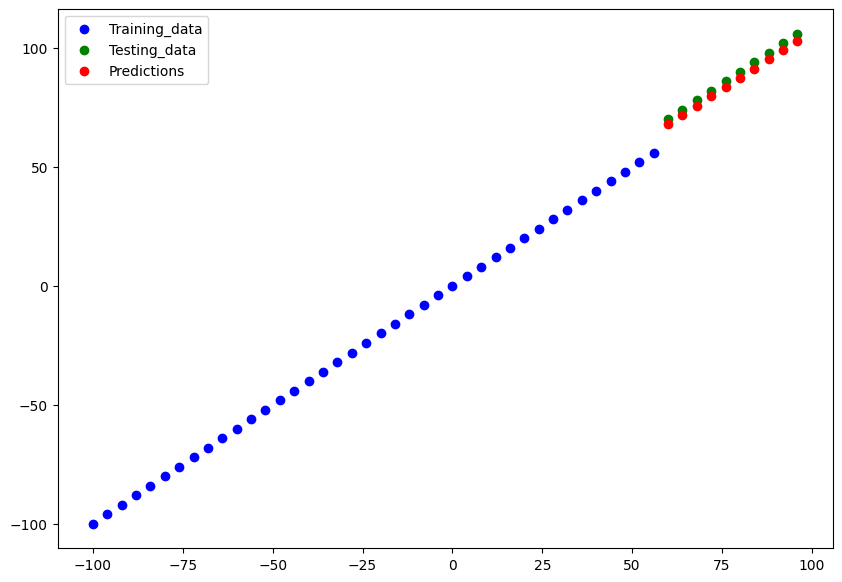

In [ ]:
plot_prediction()

In [ ]:
# Evaluating the model with the evaluating metrics
#mAE mean absolute error, " on avg how wrong is each of my model's predictions "
# MSE - mean square error, " square the average errors"
# tf.keras.losses.MAE()
# tf.keras.losses.MSE()
# HUBER : tf.keras.losses.Huber()

In [ ]:
# Evaluate the model on the test
model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 2.4924 - mae: 2.4924


[2.492394208908081, 2.492394208908081]

In [ ]:
y_pred

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 68.06964 ,  71.94621 ,  75.82254 ,  79.698715,  83.5744  ,
        87.45008 ,  91.323166,  95.19411 ,  99.06433 , 102.93286 ],
      dtype=float32)>

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [ ]:
# Claculate the MAE
Error=tf.keras.losses.MAE(y_test,y_pred)

In [ ]:
print(Error)

tf.Tensor(2.4923942, shape=(), dtype=float32)


In [ ]:
Error2=tf.keras.losses.MSE(y_test,y_pred)

In [ ]:
print(Error2)

tf.Tensor(6.3431153, shape=(), dtype=float32)


In [ ]:
#calculate the mae
mae = tf.keras.losses.mae(y_test, y_pred)

print(mae)

tf.Tensor(2.4923942, shape=(), dtype=float32)


In [ ]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 68.06964 ,  71.94621 ,  75.82254 ,  79.698715,  83.5744  ,
        87.45008 ,  91.323166,  95.19411 ,  99.06433 , 102.93286 ],
      dtype=float32)>

In [ ]:
# Calculate the mean absolute error
mae=tf.keras.losses.mae(y_true=y_test,
                        y_pred=tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=2.492394208908081>

In [ ]:
# Calculate the mean squared error
mse=tf.keras.losses.mse(y_true=y_test,
                                  y_pred=tf.squeeze(y_pred))
mse

<tf.Tensor: shape=(), dtype=float32, numpy=6.343115329742432>

In [ ]:
# Use MAE when:

# ✅ You want robustness to outliers
# ✅ Large mistakes should NOT dominate training
# ✅ Errors should be treated equally
# ✅ Regression problems with noisy data

# Real-world examples
# House prices with a few extreme mansions 🏰
# Weather prediction


# Use MSE when:

# ✅ You want to punish large errors heavily
# ✅ Big mistakes are dangerous
# ✅ Smooth gradient optimization is needed
# ✅ Deep learning regression tasks

# Real-world examples
# Stock prediction 📈
# Medical prediction 🩺
# Self-driving cars 🚗
# Scientific measurements

In [ ]:
# Make some functions to reuse the mae and the mse
def mae(y_true,y_pred):
  return tf.keras.losses.mae(y_true=y_true,
                              y_pred=y_pred)

def mse(y_true,y_pred):
  return tf.keras.losses.mse(y_true=y_true,
                              y_pred=y_pred)

In [ ]:
# Running experiment to improve our model
# 1> Getmore data-> get more example -> more oppurtunities ( to learn th epatterns and the relationships between the features and labels)
# 2> Make your model Larger ( using a more complex model)- this might come in the form of more layers or more hidden units in each layer
# 3> train for longer -> give your model mode of chance to find the pattern of the data



In [ ]:
X_train

<tf.Tensor: shape=(40, 1), dtype=int32, numpy=
array([[-100],
       [ -96],
       [ -92],
       [ -88],
       [ -84],
       [ -80],
       [ -76],
       [ -72],
       [ -68],
       [ -64],
       [ -60],
       [ -56],
       [ -52],
       [ -48],
       [ -44],
       [ -40],
       [ -36],
       [ -32],
       [ -28],
       [ -24],
       [ -20],
       [ -16],
       [ -12],
       [  -8],
       [  -4],
       [   0],
       [   4],
       [   8],
       [  12],
       [  16],
       [  20],
       [  24],
       [  28],
       [  32],
       [  36],
       [  40],
       [  44],
       [  48],
       [  52],
       [  56]], dtype=int32)>

In [ ]:
y_train

<tf.Tensor: shape=(40,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66], dtype=int32)>

In [ ]:
# lets do 3 modeling experirment
# 1. model1 -> same as the original model , 1 layer,, trined for 100 epochs.
# 2. model2 -> 2 ayers trained for 100 epochs.
# 3. model3-> 3 layers trained fr 500 epochs.
 # build model 1


In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
# Fix shape
# X_train = tf.expand_dims(X_train, axis=-1)
# X_test = tf.expand_dims(X_test, axis=-1)

# Build model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile
model_1.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Train
model_1.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 73.1437 - mae: 73.1437 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 51.3877 - mae: 51.3877
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 42.7631 - mae: 42.7631
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 41.1086 - mae: 41.1086
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 40.7598 - mae: 40.7598
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 40.7367 - mae: 40.7367
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 40.7350 - mae: 40.7350
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 40.7326 - mae: 40.7326
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 40.7314 - mae: 40.7314
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 40.7307 - mae: 40.7307
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 40.7299 - mae: 40.7299
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 40.7296 - mae: 40.7296
Epoch 13/100
2/2 ━━━━━━━

In [ ]:
X_train

<tf.Tensor: shape=(40, 1, 1, 1, 1, 1), dtype=int32, numpy=
array([[[[[[-100]]]]],




       [[[[[ -96]]]]],




       [[[[[ -92]]]]],




       [[[[[ -88]]]]],




       [[[[[ -84]]]]],




       [[[[[ -80]]]]],




       [[[[[ -76]]]]],




       [[[[[ -72]]]]],




       [[[[[ -68]]]]],




       [[[[[ -64]]]]],




       [[[[[ -60]]]]],




       [[[[[ -56]]]]],




       [[[[[ -52]]]]],




       [[[[[ -48]]]]],




       [[[[[ -44]]]]],




       [[[[[ -40]]]]],




       [[[[[ -36]]]]],




       [[[[[ -32]]]]],




       [[[[[ -28]]]]],




       [[[[[ -24]]]]],




       [[[[[ -20]]]]],




       [[[[[ -16]]]]],




       [[[[[ -12]]]]],




       [[[[[  -8]]]]],




       [[[[[  -4]]]]],




       [[[[[   0]]]]],




       [[[[[   4]]]]],




       [[[[[   8]]]]],




       [[[[[  12]]]]],




       [[[[[  16]]]]],




       [[[[[  20]]]]],




       [[[[[  24]]]]],




       [[[[[  28]]]]],




       [[[[[  32]]]]],




       [[[[[  36]]]]],


In [ ]:
X_train = X[:40]
X_test = X[40:]

# Add ONLY one dimension
X_train = tf.expand_dims(X_train, axis=-1)
X_test = tf.expand_dims(X_test, axis=-1)

print(X_train.shape)

(40, 1)


In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
# Fix shape
# X_train = tf.expand_dims(X_train, axis=-1)
# X_test = tf.expand_dims(X_test, axis=-1)

# Build model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile
model_1.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Train
model_1.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 29.3967 - mae: 29.3967 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.3441 - mae: 9.3441
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 10.5097 - mae: 10.5097
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.1047 - mae: 10.1047
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.6277 - mae: 11.6277
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.0712 - mae: 9.0712
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 10.1819 - mae: 10.1819
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 9.8318 - mae: 9.8318
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.2331 - mae: 11.2331
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.7983 - mae: 8.7983
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.9077 - mae: 9.9077  
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.3627 - mae: 11.3627
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


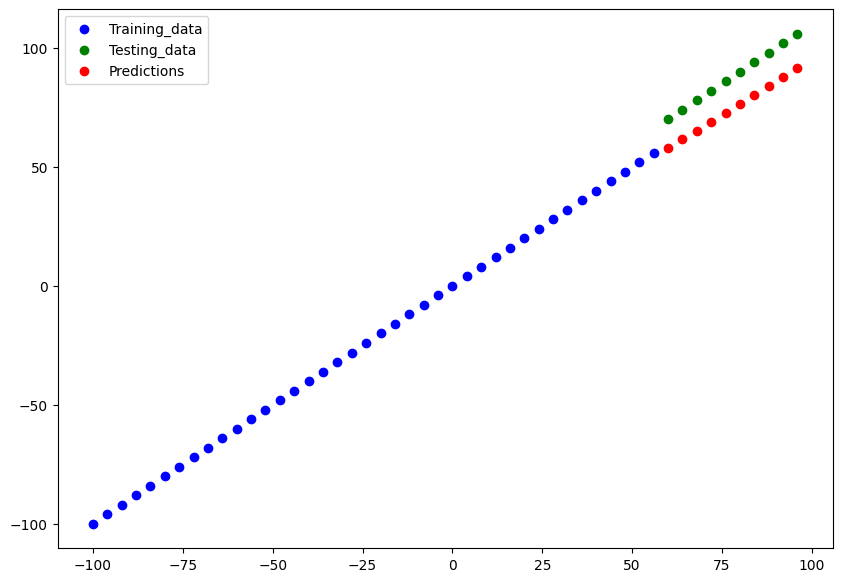

In [ ]:
# make an plot prediction for model_1
y_pred_1=model_1.predict(X_test)
plot_prediction(predictions=y_pred_1)

In [ ]:
# Calculate model_1 evaluation materic
mae_1= mae(y_test, tf.squeeze(y_pred_1))
mse_1= mse(y_test, tf.squeeze(y_pred_1))
mae_1,mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=13.288549423217773>,
 <tf.Tensor: shape=(), dtype=float32, numpy=177.0641632080078>)

In [ ]:
def mae(y_true,y_pred):
  return tf.keras.losses.mae(y_true=y_true,
                              y_pred=tf.squeeze(y_pred))

def mse(y_true,y_pred):
  return tf.keras.losses.mse(y_true=y_true,
                              y_pred=tf.squeeze(y_pred))

In [ ]:
mae

<function __main__.mae(y_true, y_pred)>

In [ ]:
mae_1= mae(y_test, y_pred_1)
mse_1= mse(y_test, y_pred_1)
mae_1,mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=13.288549423217773>,
 <tf.Tensor: shape=(), dtype=float32, numpy=177.0641632080078>)

In [ ]:
## build model_2
# 2 dense layers prpare for the predictions
tf.random.set_seed(42)
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile
model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Train
model_2.fit(X_train, y_train, epochs=100)



Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 48.0273 - mae: 48.0273 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 25.0187 - mae: 25.0187
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 22.8969 - mae: 22.8969
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 19.4286 - mae: 19.4286
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 17.6556 - mae: 17.6556
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 16.8792 - mae: 16.8792
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 12.3408 - mae: 12.3408
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 14.5991 - mae: 14.5991
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 15.8007 - mae: 15.8007
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 12.4113 - mae: 12.4113
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 14.9994 - mae: 14.9994
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.5469 - mae: 11.5469
Epoch 13/100
2/2 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


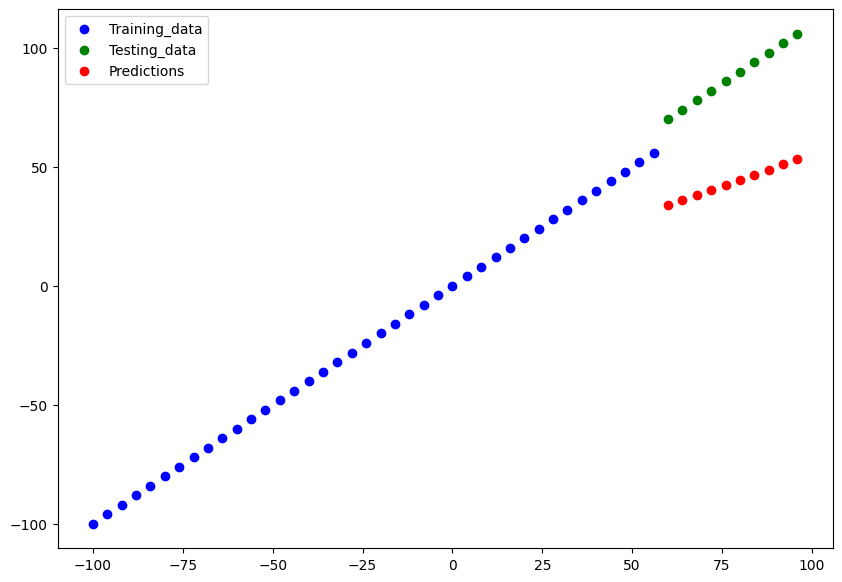

In [ ]:
# MAke and plot predictions
y_preds_2=model_2.predict(X_test)
plot_prediction(predictions=y_preds_2)

In [ ]:
# Calculta emodel_2 evaluation matrix
mae_2=mae(y_test,y_preds_2)

In [ ]:
mse_2,mae_2

(<tf.Tensor: shape=(), dtype=float32, numpy=2003.891357421875>,
 <tf.Tensor: shape=(), dtype=float32, numpy=44.44947052001953>)

In [ ]:
tf.random.set_seed(42)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile
model_3.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Train
model_3.fit(X_train, y_train, epochs=500)


Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 34.0764 - mae: 34.0764 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 26.4850 - mae: 26.4850
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 23.5397 - mae: 23.5397
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 22.7960 - mae: 22.7960
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 15.9739 - mae: 15.9739
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 18.5184 - mae: 18.5184
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 14.0586 - mae: 14.0586
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 15.0294 - mae: 15.0294
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 15.6230 - mae: 15.6230
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 12.2580 - mae: 12.2580
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 14.8061 - mae: 14.8061
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 15.6426 - mae: 15.6426
Epoch 13/500
2/2 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


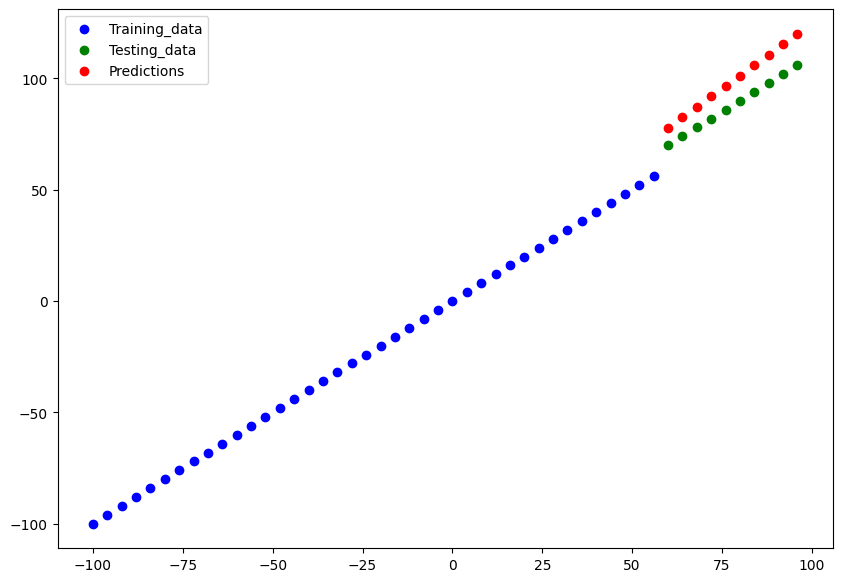

In [ ]:
y_preds_3=model_3.predict(X_test)
plot_prediction(predictions=y_preds_3)

In [ ]:
mae_3=mae(y_test,y_preds_3)

In [ ]:
mae_3

<tf.Tensor: shape=(), dtype=float32, numpy=10.9541654586792>

In [ ]:
mse_3=mse(y_test,y_preds_3)

In [ ]:
mse_3

<tf.Tensor: shape=(), dtype=float32, numpy=123.924560546875>

In [ ]:
# comparing the results of experiments

In [ ]:
 # Comparing and tackle experiments
 # lets compare our model result using pandas dataframe

In [ ]:
import pandas as pd
model_results=[["model_1",mae_1.numpy(),mse_1.numpy()],
               ["model_2",mae_2.numpy(),mse_2.numpy()],
               ["model_3",mae_3.numpy(),mse_3.numpy()]]

all_results=pd.DataFrame(model_results, columns=["model","mae","mse"])
all_results

,model,mae,mse
0,model_1,13.288549,177.064163
1,model_2,44.449471,2003.891357
2,model_3,10.954165,123.924561


In [ ]:
model_3.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# One of your main goal is to minimize the time beteen the experiments
# The more experiments you do, the more things you'll figure out which don't work and in turn , get closer to figuring out what does work. remember the machine learning practitioner mtto : experiment,experiment,experiment
# saving our models.


In [ ]:
# saving our model allows us to use them outside the google colab
#1) save model format
#2) The HDF% format

model_3.save("Best_model.keras")

In [ ]:
# loading in saved model
new_model=tf.keras.models.load_model("Best_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
new_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (260.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33 (136.00 B)

In [ ]:
model_3.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# load the h5 format
load_h5_model=tf.keras.models.load_model("/content/Best_model.h5")
load_h5_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# check to see if loaded h5 precdictionsa resame or not
model_3_preds=model_3.predict(X_test)
load_h5_model_preds=load_h5_model.predict(X_test)
model_3_preds== load_h5_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [ ]:
# Download the model from google colab
from google.colab import files
files.downloaded("#Path of file")